In [1]:
import pandas as pd

from tornadoq.benchmark_models import get_binary_estimators, get_multiclass_estimators
from tornadoq.preprocess import PreprocessConfig, split_xy, build_preprocessor
from tornadoq.evaluate_classical_benchmarks import (
    cv_evaluate_binary,
    cv_evaluate_multiclass,
    fit_and_eval_binary_many,
    fit_and_eval_multiclass_many,
)
from tornadoq.io import load_train_val_test
from tornadoq.config import CVConfig


models_to_test = ["xgb"]

TRAIN = "../Data/original/2025-Quantathon-Tornado-Q-training_data-640-examples.xlsx"
VAL   = "../Data/original/2025-Quantum-Tornado-validation_data-160-examples.xlsx"
TEST  = "../Data/original/2025-Quantum-Tornado-Q-test_data-200-examples.xlsx"

df_tr, df_va, df_te = load_train_val_test(TRAIN, VAL, TEST)
cv_cfg = CVConfig(folds=5, shuffle=True, random_state=42, repeats=1)

# =========================
# BINARY
# =========================
X_tr_b, X_va_b, y_tr_b, y_va_b = split_xy(df_tr, df_va, target="ef_binary")
_,     X_te_b, _,     y_te_b   = split_xy(df_tr, df_te, target="ef_binary")

pre_b = build_preprocessor(X_tr_b, PreprocessConfig(scaler="minmax"))
binary_models = get_binary_estimators(pre_b, use_smote=True, models_to_test=models_to_test)

binary_cv_tbl = cv_evaluate_binary(binary_models, X_tr_b, y_tr_b, cv_cfg)
binary_best = binary_cv_tbl.index[0]

# Evaluate best on VAL
binary_val_res = fit_and_eval_binary_many(
    {"best": binary_models[binary_best]},
    X_tr_b, y_tr_b,
    X_va_b, y_va_b,
)["best"]

# Final: fit on TRAIN+VAL, evaluate TEST
X_trva_b = pd.concat([X_tr_b, X_va_b], axis=0, ignore_index=True)
y_trva_b = pd.concat([y_tr_b, y_va_b], axis=0, ignore_index=True)

binary_test_res = fit_and_eval_binary_many(
    {"best": binary_models[binary_best]},
    X_trva_b, y_trva_b,
    X_te_b, y_te_b,
)["best"]

binary_best, binary_val_res, binary_test_res


# =========================
# MULTICLASS
# =========================
X_tr_m, X_va_m, y_tr_m, y_va_m = split_xy(df_tr, df_va, target="ef_class")
_,     X_te_m, _,     y_te_m   = split_xy(df_tr, df_te, target="ef_class")

pre_m = build_preprocessor(X_tr_m, PreprocessConfig(scaler="minmax"))
multiclass_models = get_multiclass_estimators(preprocessor=pre_m, use_smote=True, models_to_test=models_to_test)

multiclass_cv_tbl = cv_evaluate_multiclass(multiclass_models, X_tr_m, y_tr_m, cv_cfg)
multiclass_best = multiclass_cv_tbl.index[0]

multiclass_val_res = fit_and_eval_multiclass_many(
    {"best": multiclass_models[multiclass_best]},
    X_tr_m, y_tr_m,
    X_va_m, y_va_m,
)["best"]

X_trva_m = pd.concat([X_tr_m, X_va_m], axis=0, ignore_index=True)
y_trva_m = pd.concat([y_tr_m, y_va_m], axis=0, ignore_index=True)

multiclass_test_res = fit_and_eval_multiclass_many(
    {"best": multiclass_models[multiclass_best]},
    X_trva_m, y_trva_m,
    X_te_m, y_te_m,
)["best"]

multiclass_best, multiclass_val_res, multiclass_test_res


('xgb',
 {'test_accuracy': 0.59375,
  'report': '              precision    recall  f1-score   support\n\n        EF-0       0.71      0.72      0.72        83\n        EF-1       0.57      0.55      0.56        60\n        EF-2       0.12      0.15      0.13        13\n        EF-3       0.00      0.00      0.00         4\n\n    accuracy                           0.59       160\n   macro avg       0.35      0.36      0.35       160\nweighted avg       0.59      0.59      0.59       160\n'},
 {'test_accuracy': 0.57,
  'report': '              precision    recall  f1-score   support\n\n        EF-0       0.69      0.70      0.70       104\n        EF-1       0.57      0.48      0.52        75\n        EF-2       0.20      0.31      0.24        16\n        EF-3       0.00      0.00      0.00         5\n\n    accuracy                           0.57       200\n   macro avg       0.37      0.37      0.37       200\nweighted avg       0.59      0.57      0.58       200\n'})

In [2]:
import pandas as pd
from sklearn.base import clone
from tornadoq.config import CVConfig
from tornadoq.evaluate_classical_benchmarks import fit_and_eval_binary

# --- CV on TRAIN only ---
binary_cv_tbl = cv_evaluate_binary(binary_models, X_tr_b, y_tr_b, CVConfig(folds=5))

metric = "cv_roc_auc_mean"  # <-- change to whatever column cv_evaluate_binary returns
binary_best = binary_cv_tbl.sort_values(metric, ascending=False).index[0]

# --- Evaluate chosen model on VAL ---
val_res = fit_and_eval_binary(
    clone(binary_models[binary_best]),
    X_tr_b, y_tr_b,
    X_va_b, y_va_b,
)

# --- Final: fit on TRAIN+VAL, report TEST ---
X_trva_b = pd.concat([X_tr_b, X_va_b], axis=0, ignore_index=True)
y_trva_b = pd.concat([y_tr_b, y_va_b], axis=0, ignore_index=True)

test_res = fit_and_eval_binary(
    clone(binary_models[binary_best]),
    X_trva_b, y_trva_b,
    X_te_b, y_te_b,
)

binary_best, val_res, test_res


('xgb',
 {'test_roc_auc': 0.5034965034965035,
  'test_accuracy': 0.8125,
  'report': '               precision    recall  f1-score   support\n\n Weak (EF0-1)       0.91      0.88      0.89       143\nStrong (EF2+)       0.19      0.24      0.21        17\n\n     accuracy                           0.81       160\n    macro avg       0.55      0.56      0.55       160\n weighted avg       0.83      0.81      0.82       160\n'},
 {'test_roc_auc': 0.6648044692737429,
  'test_accuracy': 0.82,
  'report': '               precision    recall  f1-score   support\n\n Weak (EF0-1)       0.91      0.88      0.90       179\nStrong (EF2+)       0.22      0.29      0.25        21\n\n     accuracy                           0.82       200\n    macro avg       0.57      0.58      0.57       200\n weighted avg       0.84      0.82      0.83       200\n'})

In [3]:
import pandas as pd
from sklearn.base import clone
from tornadoq.config import CVConfig
from tornadoq.evaluate_classical_benchmarks import fit_and_eval_multiclass

# --- CV on TRAIN only ---
multiclass_cv_tbl = cv_evaluate_multiclass(
    multiclass_models,
    X_tr_m, y_tr_m,
    CVConfig(folds=5)
)
multiclass_cv_tbl.head()

metric = "cv_acc_mean"  # change if your CV table uses a different column
multiclass_best = multiclass_cv_tbl.sort_values(metric, ascending=False).index[0]

# --- Evaluate chosen model on VAL ---
val_res_multi = fit_and_eval_multiclass(
    clone(multiclass_models[multiclass_best]),
    X_tr_m, y_tr_m,
    X_va_m, y_va_m,
)

# --- Final: fit on TRAIN+VAL, report TEST ---
X_trva_m = pd.concat([X_tr_m, X_va_m], axis=0, ignore_index=True)
y_trva_m = pd.concat([y_tr_m, y_va_m], axis=0, ignore_index=True)

test_res_multi = fit_and_eval_multiclass(
    clone(multiclass_models[multiclass_best]),
    X_trva_m, y_trva_m,
    X_te_m, y_te_m,
)

multiclass_best, val_res_multi, test_res_multi


('xgb',
 {'test_accuracy': 0.59375,
  'report': '              precision    recall  f1-score   support\n\n        EF-0       0.71      0.72      0.72        83\n        EF-1       0.57      0.55      0.56        60\n        EF-2       0.12      0.15      0.13        13\n        EF-3       0.00      0.00      0.00         4\n\n    accuracy                           0.59       160\n   macro avg       0.35      0.36      0.35       160\nweighted avg       0.59      0.59      0.59       160\n'},
 {'test_accuracy': 0.57,
  'report': '              precision    recall  f1-score   support\n\n        EF-0       0.69      0.70      0.70       104\n        EF-1       0.57      0.48      0.52        75\n        EF-2       0.20      0.31      0.24        16\n        EF-3       0.00      0.00      0.00         5\n\n    accuracy                           0.57       200\n   macro avg       0.37      0.37      0.37       200\nweighted avg       0.59      0.57      0.58       200\n'})

In [ ]:
from torch.utils.data import DataLoader
from tornadoq.preprocessing import ClassificationDataset, Preprocess, DataMaker

withShadows = True

# Data paths
TRAIN_FILE = "../Data/original/2025-Quantathon-Tornado-Q-training_data-640-examples.xlsx"
TEST_FILE = "../Data/original/2025-Quantum-Tornado-Q-test_data-200-examples.xlsx"
VALIDATION_FILE = '../Data/original/2025-Quantum-Tornado-validation_data-160-examples.xlsx'

# Create pandas dataframes
df_train, df_test, df_val = DataMaker(TRAIN_FILE, TEST_FILE, VALIDATION_FILE, withShadows = withShadows, output_filename="original_shadow_enhanced.csv")

print()
print(df_train.columns.tolist())

classifier = 'binary'

# Preprocessing
X_train, y_train, X_test, y_test, X_val, y_val = Preprocess(df_train, df_test, df_val, balance = 'smote', classes = classifier)

print()
print(y_val)


train_data = ClassificationDataset(X_train, y_train)
validation_data = ClassificationDataset(X_val, y_val)
test_data = ClassificationDataset(X_test, y_test)

# Dataloaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, drop_last=True)
val_loader = DataLoader(validation_data, batch_size=64, shuffle=False, drop_last=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, drop_last=True)

print("\nNumber of training samples:", len(train_data))
print("Number of validation samples:", len(validation_data))
print("Number of test samples:", len(test_data))

<class 'tornadoq.models.MulticlassDNN'>
Epoch [1] had best val_metric
Epoch [1] had best val_Loss
Epoch [2] had best val_Loss
Epoch [3] had best val_Loss
Epoch [5/45] | Train Loss: 1.3237 | Train Acc: 0.3281 | Val Loss: 13.2398 | Val Acc: 3.6875
Epoch [5] had best val_metric
Epoch [7] had best val_metric
Epoch [7] had best val_Loss
Epoch [9] had best val_metric
Epoch [9] had best val_Loss
Epoch [10/45] | Train Loss: 1.2506 | Train Acc: 0.4180 | Val Loss: 11.9409 | Val Acc: 4.5703
Epoch [10] had best val_metric
Epoch [11] had best val_metric
Epoch [11] had best val_Loss
Epoch [13] had best val_metric
Epoch [13] had best val_Loss
Epoch [15/45] | Train Loss: 1.2002 | Train Acc: 0.4641 | Val Loss: 11.3208 | Val Acc: 4.6875
Epoch [15] had best val_Loss
Epoch [16] had best val_metric
Epoch [16] had best val_Loss
Epoch [17] had best val_metric
Epoch [18] had best val_metric
Epoch [18] had best val_Loss
Epoch [19] had best val_Loss
Epoch [20/45] | Train Loss: 1.1722 | Train Acc: 0.4789 | Val L

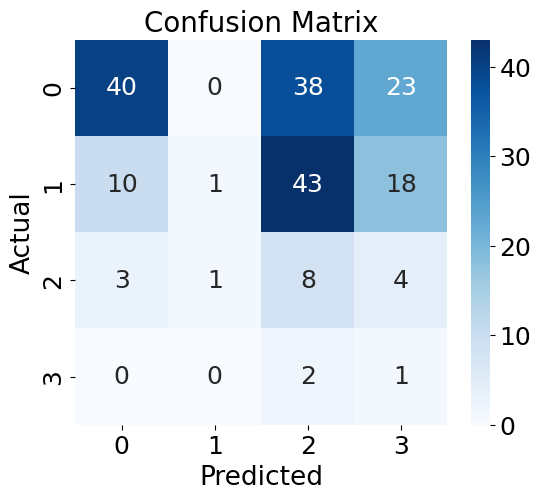

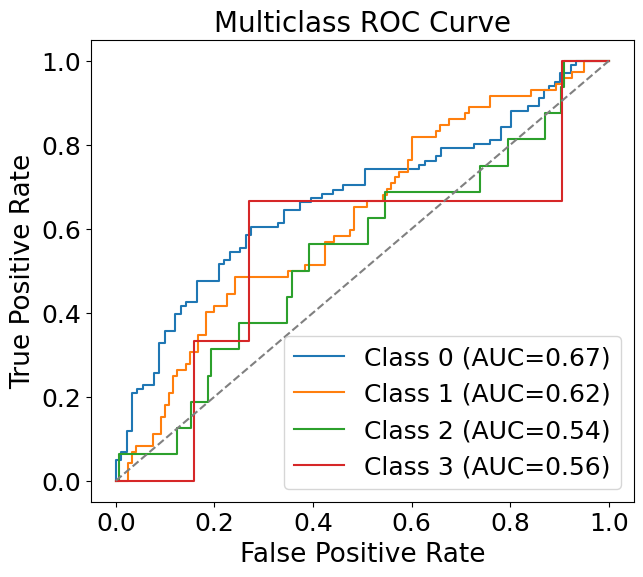

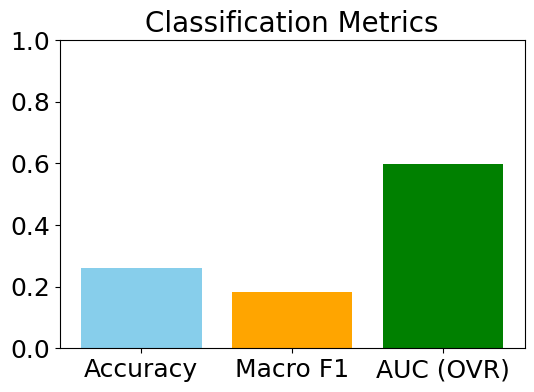

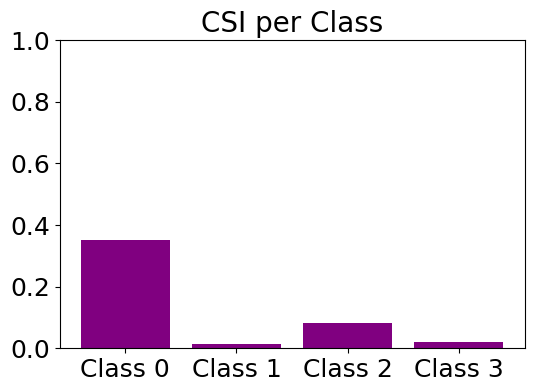

In [ ]:
from tornadoq.train import train
from tornadoq.models import InitializeModel
from tornadoq.loadSaveEval import eval_model, save

# Choose model and hyperparameters
# model = "DNN"
model = "StronglyEntangling"
# model = "RandomLayer"
n_epochs = 45
lr = .01

# Initialize, train, and evaluate model
model = InitializeModel(model, load_path = None, classifier = classifier, input_size = 8)
print(type(model))
train(model = model, n_epochs = n_epochs, lr = lr, train_loader = train_loader, val_loader = val_loader, classifier = classifier)
eval_model(model = model, test_loader = test_loader, classifier = classifier, fontsize = 18)

# Training automatically saves the best performing model paramters
# Optionally, save the final model parameters
# save(model = model, save_path = None)
# Or load a previously trained model
# load(model = model, load_path = "")

<class 'tornadoq.models.BinaryPQC'>
Epoch [1] had best val_metric
Epoch [1] had best val_Loss
Epoch [2] had best val_Loss
Epoch [3] had best val_Loss
Epoch [5/45] | Train Loss: 0.6450 | Train Acc: 32.1176 | Val Loss: 5.4512 | Val Acc: 271.5000
Epoch [5] had best val_Loss
Epoch [7] had best val_Loss
Epoch [8] had best val_Loss
Epoch [10/45] | Train Loss: 0.6245 | Train Acc: 32.1765 | Val Loss: 5.1924 | Val Acc: 274.0000
Epoch [10] had best val_metric
Epoch [10] had best val_Loss
Epoch [12] had best val_Loss
Epoch [14] had best val_Loss
Epoch [15/45] | Train Loss: 0.6165 | Train Acc: 32.2941 | Val Loss: 5.1191 | Val Acc: 272.5000
Epoch [15] had best val_Loss
Epoch [16] had best val_Loss
Epoch [17] had best val_metric
Epoch [20/45] | Train Loss: 0.6061 | Train Acc: 31.7647 | Val Loss: 5.0585 | Val Acc: 275.0000
Epoch [20] had best val_Loss
Epoch [25/45] | Train Loss: 0.6022 | Train Acc: 32.0000 | Val Loss: 5.1111 | Val Acc: 269.0000
Epoch [28] had best val_metric
Epoch [30/45] | Train Los

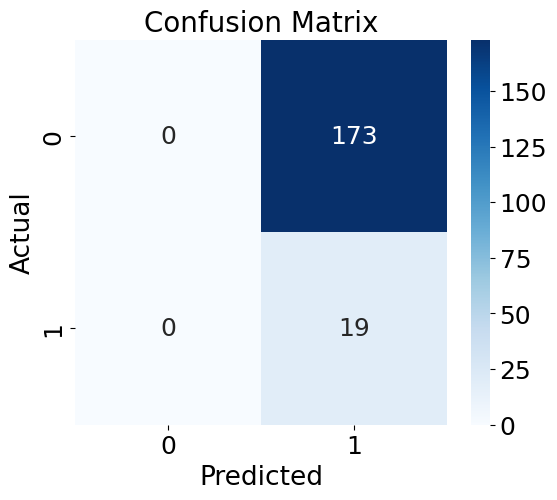

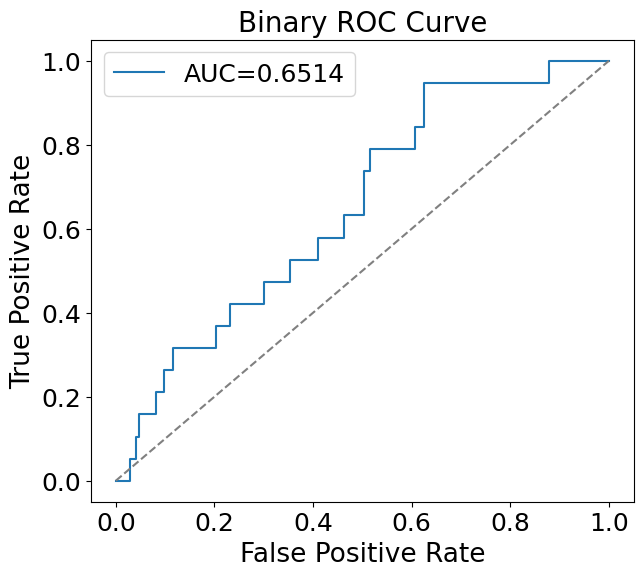

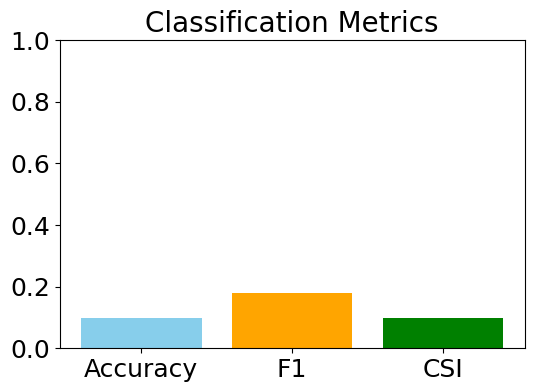

In [ ]:
from tornadoq.train import train
from tornadoq.models import InitializeModel
from tornadoq.loadSaveEval import eval_model, save

# Choose model and hyperparameters
# model = "DNN"
# model = "StronglyEntangling"
model = "RandomLayer"
n_epochs = 45
lr = .01

# Initialize, train, and evaluate model
model = InitializeModel(model, load_path = None, classifier = classifier, input_size = 8)
print(type(model))
train(model = model, n_epochs = n_epochs, lr = lr, train_loader = train_loader, val_loader = val_loader, classifier = classifier)
eval_model(model = model, test_loader = test_loader, classifier = classifier, fontsize = 18)

# Training automatically saves the best performing model paramters
# Optionally, save the final model parameters
# save(model = model, save_path = None)
# Or load a previously trained model
# load(model = model, load_path = "")

<class 'tornadoq.models.BinaryPQC'>
Epoch [1] had best val_metric
Epoch [1] had best val_Loss
Epoch [2] had best val_metric
Epoch [2] had best val_Loss
Epoch [3] had best val_metric
Epoch [3] had best val_Loss
Epoch [4] had best val_Loss
Epoch [5/45] | Train Loss: 0.6267 | Train Acc: 32.0000 | Val Loss: 5.2734 | Val Acc: 268.5000
Epoch [5] had best val_Loss
Epoch [6] had best val_metric
Epoch [7] had best val_metric
Epoch [7] had best val_Loss
Epoch [9] had best val_Loss
Epoch [10/45] | Train Loss: 0.6172 | Train Acc: 31.9412 | Val Loss: 5.2272 | Val Acc: 273.5000
Epoch [12] had best val_Loss
Epoch [15/45] | Train Loss: 0.6277 | Train Acc: 31.8235 | Val Loss: 5.1164 | Val Acc: 272.0000
Epoch [16] had best val_Loss
Epoch [20/45] | Train Loss: 0.6034 | Train Acc: 31.7059 | Val Loss: 5.2096 | Val Acc: 272.0000
Epoch [21] had best val_Loss
Epoch [25/45] | Train Loss: 0.6032 | Train Acc: 31.8235 | Val Loss: 5.0099 | Val Acc: 277.0000
Epoch [25] had best val_metric
Epoch [25] had best val_Lo

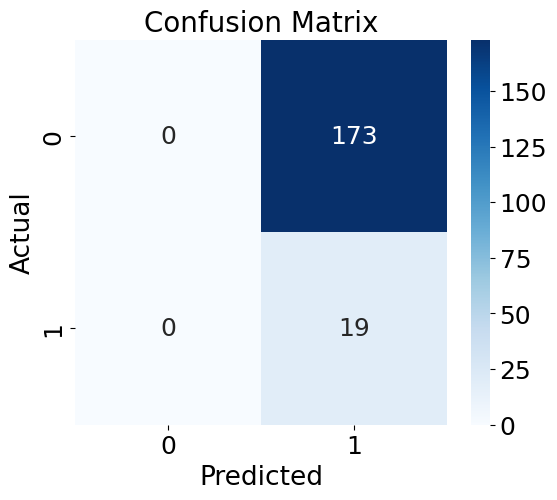

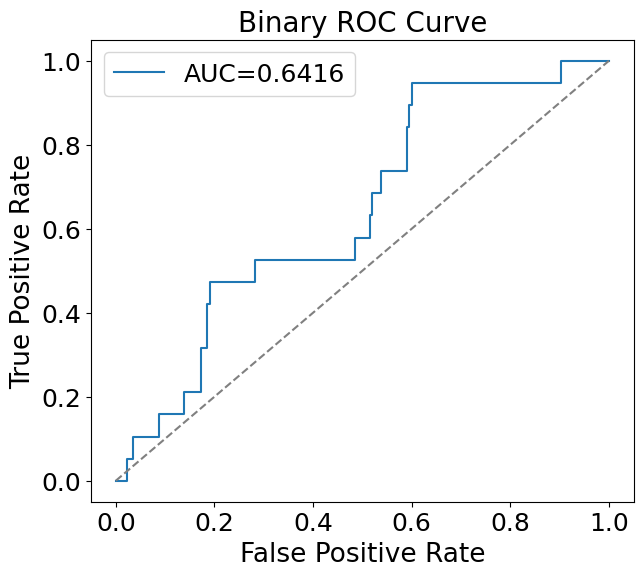

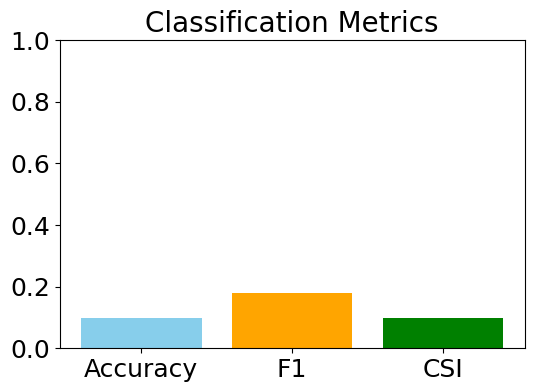

In [ ]:
from tornadoq.train import train
from tornadoq.models import InitializeModel
from tornadoq.loadSaveEval import eval_model, save

# Choose model and hyperparameters
# model = "DNN"
# model = "StronglyEntangling"
model = "RandomLayer"
n_epochs = 45
lr = .01

# Initialize, train, and evaluate model
model = InitializeModel(model, load_path = None, classifier = classifier, input_size = 8)
print(type(model))
train(model = model, n_epochs = n_epochs, lr = lr, train_loader = train_loader, val_loader = val_loader, classifier = classifier)
eval_model(model = model, test_loader = test_loader, classifier = classifier, fontsize = 18)

# Training automatically saves the best performing model paramters
# Optionally, save the final model parameters
# save(model = model, save_path = None)
# Or load a previously trained model
# load(model = model, load_path = "")